# Wiener Filter

`wiener_filter` is a frequency-domain denoiser. It estimates the signal PSD,
subtracts a constant white-noise level `noise_variance`, and applies the Wiener
gain $H(f) = P_{s}(f) / (P_{s}(f) + \sigma^2_n)$. Optional `window_size` is
accepted for API completeness; the current implementation uses a full-length FFT.

This is most visible when the input is a **clean oscillation plus known noise**.
If `noise_variance` is far below the actual noise power the filter barely moves;
if it is far above, the series is over-smoothed.

| Parameter | Default | Role |
| --- | --- | --- |
| `noise_variance` | 1.0 | Assumed white-noise PSD level |
| `window_size` | None | Currently unused beyond defaulting to `len(series)` |


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.utils import (
    load_univariate,
    generate_arma_samples,
    generate_nonstationary_sine,
    generate_chirp_signal,
)

L = 512
rng = np.random.RandomState(0)
np.random.seed(0)

synth = np.asarray(generate_arma_samples(L), dtype=float)
real = load_univariate("ETTh1")[:L].astype(float)


def overlay_pair(originals, variants, titles, ylabel="value"):
    # Plot original vs augmented traces for synth (left) and real (right).
    n = len(titles)
    fig, axes = plt.subplots(
        n, 2, figsize=(11.5, 2.55 * n), sharex=False, squeeze=False
    )
    col_titles = ["synthetic (ARMA)", "real (ETTh1 OT)"]
    for col, (orig, var_list) in enumerate(zip(originals, variants)):
        for row, (label, series) in enumerate(var_list):
            ax = axes[row, col]
            ax.plot(orig, color="0.55", lw=1.15, label="original")
            ax.plot(series, color="C0", lw=1.15, alpha=0.9, label=label)
            if row == 0:
                ax.set_title(col_titles[col], fontweight="bold")
            if col == 0:
                ax.set_ylabel(ylabel)
            ax.legend(fontsize=8, loc="upper right", frameon=False)
            ax.grid(True, alpha=0.3)
            axes[row, 0].set_ylabel(titles[row], fontsize=10)
    axes[-1, 0].set_xlabel("t")
    axes[-1, 1].set_xlabel("t")
    fig.tight_layout()
    return fig


def sweep_grid(series_list, names, makers, param_title):
    # makers: list of (label, fn) applied to each series.
    n_s, n_p = len(series_list), len(makers)
    fig, axes = plt.subplots(n_s, n_p, figsize=(3.6 * n_p, 2.5 * n_s), squeeze=False)
    for i, (series, name) in enumerate(zip(series_list, names)):
        for j, (label, fn) in enumerate(makers):
            ax = axes[i, j]
            ax.plot(series, color="0.55", lw=1.0, label="original")
            ax.plot(fn(series), color="C3", lw=1.05, alpha=0.9, label=label)
            if i == 0:
                ax.set_title(label, fontsize=10)
            if j == 0:
                ax.set_ylabel(name)
            ax.grid(True, alpha=0.3)
            if i == 0 and j == n_p - 1:
                ax.legend(fontsize=7, loc="upper right", frameon=False)
    fig.suptitle(param_title, y=1.02, fontweight="bold")
    fig.tight_layout()
    return fig


from s2generator.augmentation import wiener_filter

clean = np.sin(2 * np.pi * np.arange(L) / 24.0)
noisy_s = clean + rng.normal(0.0, 0.45, L)
noisy_r = real + rng.normal(0.0, 0.15 * np.std(real), L)

## Denoising synthetic sine+noise and a noisy real slice


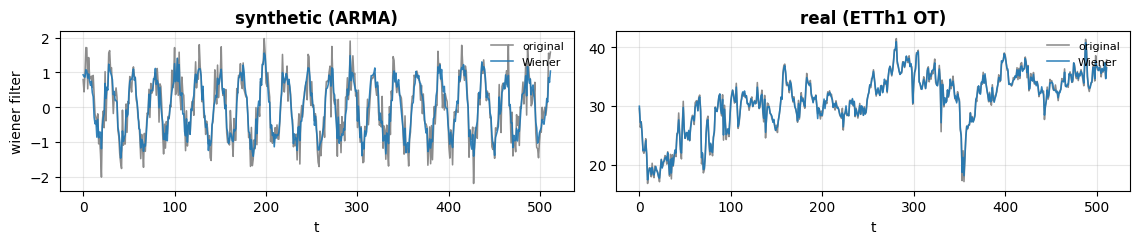

In [2]:
aug_s = wiener_filter(noisy_s, noise_variance=0.45**2)
aug_r = wiener_filter(noisy_r, noise_variance=(0.15 * np.std(real)) ** 2)
overlay_pair(
    [noisy_s, noisy_r],
    [[("Wiener", aug_s)], [("Wiener", aug_r)]],
    titles=["wiener filter"],
)
plt.show()

## Parameter effect of `noise_variance`

Too small: residual noise remains. Matched: the sine reappears. Too large: both
noise **and** signal energy are attenuated.


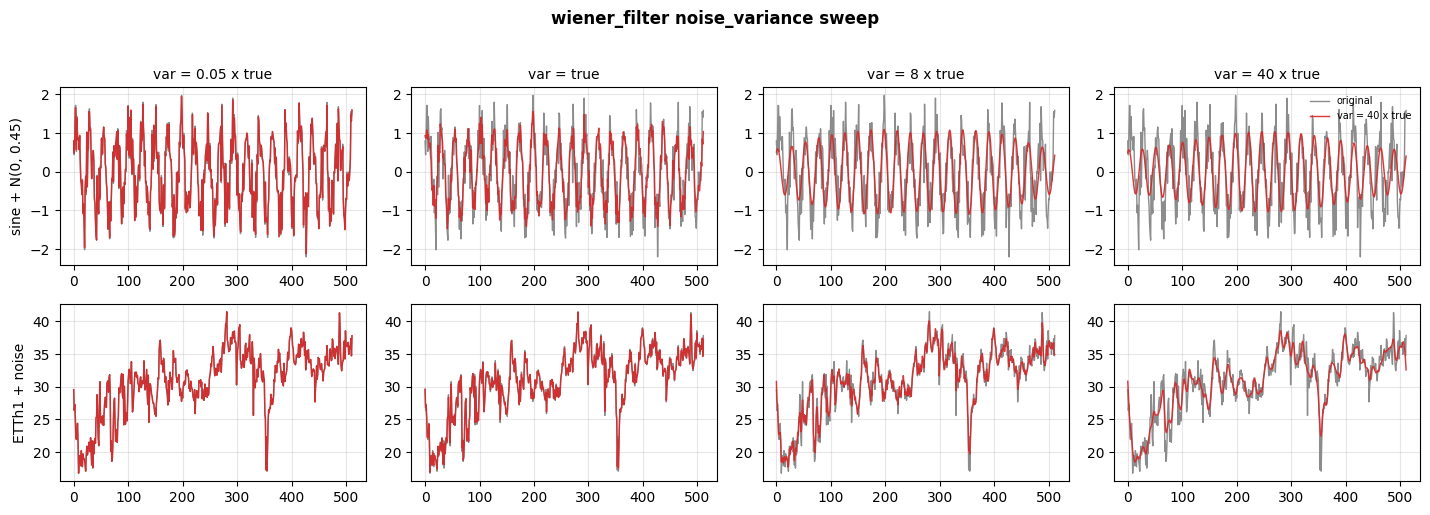

In [3]:
true_var = 0.45**2
makers = [
    ("var = 0.05 x true", lambda x: wiener_filter(x, noise_variance=0.05 * true_var)),
    ("var = true", lambda x: wiener_filter(x, noise_variance=true_var)),
    ("var = 8 x true", lambda x: wiener_filter(x, noise_variance=8 * true_var)),
    ("var = 40 x true", lambda x: wiener_filter(x, noise_variance=40 * true_var)),
]
sweep_grid(
    [noisy_s, noisy_r],
    ["sine + N(0, 0.45)", "ETTh1 + noise"],
    makers,
    "wiener_filter noise_variance sweep",
)
plt.show()